In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import plotly.express as px
import numpy as np
from scipy.spatial import KDTree

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [2]:
df = pd.read_csv("movies.csv")
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [3]:
list(df.columns)

['names',
 'date_x',
 'score',
 'genre',
 'overview',
 'crew',
 'orig_title',
 'status',
 'orig_lang',
 'budget_x',
 'revenue',
 'country']

<Axes: >

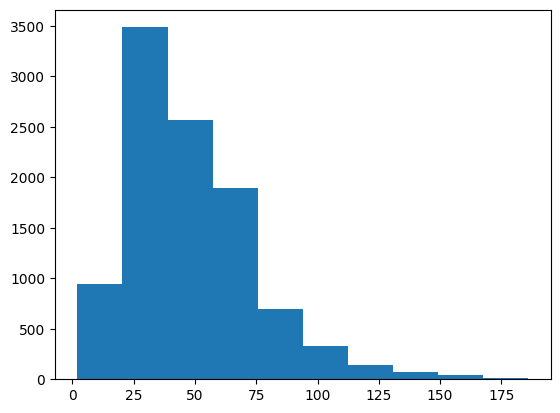

In [4]:
lens = df["overview"].apply(str.split).apply(len)
lens.hist(grid=False)

In [5]:

def textify_movie(row):
    def clean(val):
        if pd.isna(val) or val == '':
            return "Unknown"
        return str(val)

    # Grab the goods
    name = clean(row.get('names'))
    date = clean(row.get('date_x'))
    score = clean(row.get('score'))
    genres = clean(row.get('genre'))
    overview = clean(row.get('overview'))
    crew = clean(row.get('crew'))
    lang = clean(row.get('orig_lang'))
    budget = clean(row.get('budget_x'))
    rev = clean(row.get('revenue'))
    country = clean(row.get('country'))

    # Assemble the mega-string
    text = f"Title: {name}. Released in {date}, this {country} film is primarily in {lang}. "
    text += f"It falls under the {genres} genre. "
    text += f"It holds a rating of {score}/10. "
    text += f"Financially, it had a budget of ${budget} and made ${rev} in revenue. "
    text += f"Plot overview: {overview} "
    text += f"Key crew members include: {crew}."

    return text

df['content'] = df.apply(textify_movie, axis=1)

In [6]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
embeddings = model.encode(df["content"].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/319 [00:00<?, ?it/s]

In [9]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
coords = reducer.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
coords.shape

(10178, 3)

In [37]:
fig = px.scatter_3d(
    x=coords[:,0],
    y=coords[:,1],
    z=coords[:,2],
    hover_name=df["names"],
    color=df["genre"]
)

fig.update_traces(marker=dict(size=2, opacity=0.8))

fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        aspectmode='data'
    ),
    template="plotly_dark",
    showlegend=False
)

fig.show()

In [34]:
df[["x", "y", "z"]] = coords
coords

array([[-1.9337194 ,  7.299997  ,  7.9621396 ],
       [-0.76147836,  5.207555  ,  6.363059  ],
       [-0.5577612 ,  5.3765416 ,  4.2201567 ],
       ...,
       [-0.8893304 ,  6.043402  ,  8.133725  ],
       [-3.0107486 ,  6.164052  ,  5.629417  ],
       [ 0.02290532,  7.2003155 ,  4.5082555 ]], dtype=float32)

In [29]:
tree = KDTree(coords)

In [ ]:
def get_closest_movies(movie_name, df, tree, n=5):
    if movie_name not in df['names'].values:
        return "Movie not found, check your spelling."

    idx = df[df['names'] == movie_name].index[0]
    target_xyz = df.loc[idx, ['x', 'y', 'z']].values

    distances, indices = tree.query(target_xyz, k=n + 1)

    # skipping the first one, which is the reference movie
    neighbor_indices = indices[1:]

    return df.iloc[neighbor_indices]

In [30]:
get_closest_movies("Tenet", df, tree).head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,content,x,y,z
8302,Pitch Black,05/18/2000,68.0,"Thriller, Science Fiction, Action",When their ship crash-lands on a remote planet...,"Vin Diesel, Richard B. Riddick, Radha Mitchell...",Pitch Black,Released,English,23000000.0,53182088.0,AU,"Title: Pitch Black. Released in 05/18/2000 , t...",-2.288006,6.101485,6.374478
465,The Adam Project,03/11/2022,71.0,"Adventure, Science Fiction","After accidentally crash-landing in 2022, time...","Ryan Reynolds, Adam Reed, Walker Scobell, Youn...",The Adam Project,Released,English,116000000.0,203098455.6,AU,Title: The Adam Project. Released in 03/11/202...,-2.252738,6.006051,6.402600
3030,Air,10/28/2015,49.0,"Science Fiction, Thriller","In the near future, breathable air is nonexist...","Norman Reedus, Bauer, Djimon Hounsou, Cartwrig...",Air,Released,English,103600000.0,901958484.2,AU,"Title: Air. Released in 10/28/2015 , this AU f...",-2.377082,5.891317,6.403155
7006,"Tomorrow, When the War Began",08/08/2010,62.0,"Action, Adventure, Drama","Ellie Linton, a teen from an Australian coasta...","Caitlin Stasey, Ellie Linton, Rachel Hurd-Wood...","Tomorrow, When the War Began",Released,English,27000000.0,16504936.0,AU,"Title: Tomorrow, When the War Began. Released ...",-2.454365,5.903922,6.547084
3625,Serenity,09/29/2005,74.0,"Science Fiction, Action, Adventure, Thriller",When the renegade crew of Serenity agrees to h...,"Nathan Fillion, Malcolm ""Mal"" Reynolds, Summer...",Serenity,Released,English,39000000.0,40319440.0,AU,"Title: Serenity. Released in 09/29/2005 , this...",-2.243378,6.094088,6.356683


In [22]:
# df.to_csv("with_embeddings.csv")